Device : cpu | PyTorch : 2.12.0+cpu
Train : 60000 images | Test : 10000 images
Taille d'une image : torch.Size([1, 28, 28])


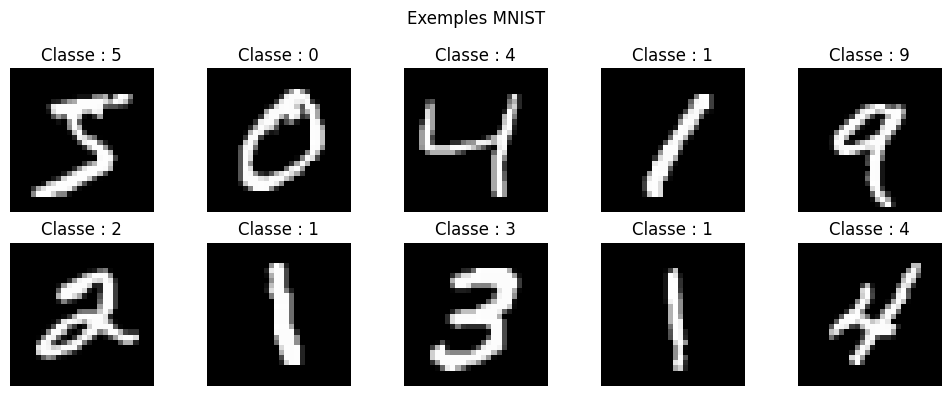

Données chargées ✓


In [1]:

# ============================================================
# PARTIE II — CNN sur images
# Dataset : MNIST (chiffres manuscrits 0-9)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ── Device ───────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device} | PyTorch : {torch.__version__}")

# ── Chargement MNIST ─────────────────────────────────────
# MNIST : 70 000 images 28x28 pixels en niveaux de gris
# 10 classes : chiffres 0 à 9
transform = transforms.Compose([
    transforms.ToTensor(),                    # image → tenseur [0,1]
    transforms.Normalize((0.1307,), (0.3081,)) # normalisation standard MNIST
])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64)

print(f"Train : {len(train_dataset)} images | Test : {len(test_dataset)} images")
print(f"Taille d'une image : {train_dataset[0][0].shape}")  # [1, 28, 28]

# ── Visualiser quelques images ───────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Classe : {label}")
    ax.axis("off")
plt.suptitle("Exemples MNIST")
plt.tight_layout()
plt.savefig("mnist_exemples.png", dpi=150)
plt.show()
print("Données chargées ✓")


In [2]:

# ============================================================
# CONVOLUTION MANUELLE (pour montrer qu'on comprend)
# ============================================================

def corr2d_manuel(X, K):
    """
    Corrélation croisée 2D manuelle.
    X : image (h, w)
    K : noyau/filtre (kh, kw)
    Retourne la carte de caractéristiques.
    """
    kh, kw = K.shape
    h_out  = X.shape[0] - kh + 1
    w_out  = X.shape[1] - kw + 1
    Y = torch.zeros(h_out, w_out)
    for i in range(h_out):
        for j in range(w_out):
            Y[i, j] = (X[i:i+kh, j:j+kw] * K).sum()
    return Y

def maxpool_manuel(X, pool_size=2):
    """Max-pooling 2x2 manuel."""
    h, w = X.shape
    h_out, w_out = h // pool_size, w // pool_size
    Y = torch.zeros(h_out, w_out)
    for i in range(h_out):
        for j in range(w_out):
            Y[i,j] = X[i*pool_size:(i+1)*pool_size,
                       j*pool_size:(j+1)*pool_size].max()
    return Y

def avgpool_manuel(X, pool_size=2):
    """Average-pooling 2x2 manuel."""
    h, w = X.shape
    h_out, w_out = h // pool_size, w // pool_size
    Y = torch.zeros(h_out, w_out)
    for i in range(h_out):
        for j in range(w_out):
            Y[i,j] = X[i*pool_size:(i+1)*pool_size,
                       j*pool_size:(j+1)*pool_size].mean()
    return Y

# ── Test sur une petite image ────────────────────────────
X_test_conv = torch.tensor([[1.,2.,3.],[4.,5.,6.],[7.,8.,9.]])
K_filtre    = torch.tensor([[1.,0.],[-1.,0.]])
resultat    = corr2d_manuel(X_test_conv, K_filtre)
print("Corrélation croisée manuelle :")
print(resultat)
print(f"Taille sortie : {resultat.shape}")  # (2, 2) attendu

# ── Vérification avec PyTorch ────────────────────────────
conv_pytorch = nn.Conv2d(1, 1, kernel_size=2, bias=False)
conv_pytorch.weight.data = K_filtre.unsqueeze(0).unsqueeze(0)
res_pt = conv_pytorch(X_test_conv.unsqueeze(0).unsqueeze(0))
print("\nMême résultat avec PyTorch :")
print(res_pt.squeeze().detach())

# ============================================================
# ARCHITECTURE LeNet (adaptée à MNIST 28x28)
# ============================================================
class LeNet(nn.Module):
    """
    Architecture inspirée de LeNet-5.
    Entrée  : [batch, 1, 28, 28]
    Sortie  : [batch, 10]  (10 classes)

    Calcul des tailles :
    Conv1(1→6, k=5, pad=2) → 28x28
    MaxPool(2)              → 14x14
    Conv2(6→16, k=5)        → 10x10
    MaxPool(2)              →  5x5
    Flatten                 → 16*5*5 = 400
    FC1(400→120) → FC2(120→84) → FC3(84→10)
    """
    def __init__(self):
        super().__init__()
        # Bloc convolutionnel 1
        self.conv1 = nn.Conv2d(1, 6,  kernel_size=5, padding=2)
        self.pool  = nn.MaxPool2d(2, 2)
        # Bloc convolutionnel 2
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        # Couche 1x1 (bonus)
        self.conv3 = nn.Conv2d(16, 16, kernel_size=1)
        # Couches fully connected
        self.fc1   = nn.Linear(16*5*5, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # → [b,6,14,14]
        x = self.pool(self.relu(self.conv2(x)))  # → [b,16,5,5]
        x = self.relu(self.conv3(x))             # conv 1x1
        x = x.view(x.size(0), -1)               # flatten → [b,400]
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

cnn_model = LeNet().to(device)
print("\n=== Architecture LeNet ===")
print(cnn_model)
print(f"Paramètres : {sum(p.numel() for p in cnn_model.parameters()):,}")


Corrélation croisée manuelle :
tensor([[-3., -3.],
        [-3., -3.]])
Taille sortie : torch.Size([2, 2])

Même résultat avec PyTorch :
tensor([[-3., -3.],
        [-3., -3.]])

=== Architecture LeNet ===
LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (relu): ReLU()
)
Paramètres : 61,978


In [3]:

# ── Fonction d'entraînement générique ────────────────────
def train_model(model, train_loader, test_loader, n_epochs=10, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history   = {"train_loss":[], "test_acc":[]}

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Évaluation sur test
        model.eval()
        correct = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                correct += (model(xb).argmax(1) == yb).sum().item()
        acc = correct / len(test_loader.dataset)
        history["train_loss"].append(total_loss / len(train_loader))
        history["test_acc"].append(acc)
        print(f"  Epoch {epoch+1:2d}/{n_epochs} | loss: {total_loss/len(train_loader):.4f} | acc: {acc:.4f}")

    return history

# ── MLP simple pour comparaison ──────────────────────────
class MLP_Images(nn.Module):
    """MLP naïf : aplatit l'image 28x28=784 → couches FC"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

# ── Entraînement CNN (LeNet) ──────────────────────────────
print("\n=== Entraînement LeNet CNN ===")
cnn_model  = LeNet().to(device)
hist_cnn   = train_model(cnn_model, train_loader, test_loader, n_epochs=10)
torch.save(cnn_model.state_dict(), "best_cnn.pth")

# ── Entraînement MLP ─────────────────────────────────────
print("\n=== Entraînement MLP (comparaison) ===")
mlp_img    = MLP_Images().to(device)
hist_mlp   = train_model(mlp_img, train_loader, test_loader, n_epochs=10)

# ── Comparaison CNN vs MLP ───────────────────────────────
print("\n=== Comparaison finale ===")
print(f"CNN (LeNet) accuracy finale : {hist_cnn['test_acc'][-1]:.4f}")
print(f"MLP accuracy finale         : {hist_mlp['test_acc'][-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(hist_cnn["test_acc"], label="CNN (LeNet)", marker="o")
plt.plot(hist_mlp["test_acc"], label="MLP",        marker="s")
plt.title("CNN vs MLP — Accuracy sur MNIST")
plt.xlabel("Époque"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig("cnn_vs_mlp.png", dpi=150)
plt.show()



=== Entraînement LeNet CNN ===
  Epoch  1/10 | loss: 0.2929 | acc: 0.9722


RuntimeError: [enforce fail at alloc_cpu.cpp:117] data. DefaultCPUAllocator: not enough memory: you tried to allocate 3211264 bytes.


=== Rapport de classification CNN ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.98      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       1.00      0.97      0.98       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



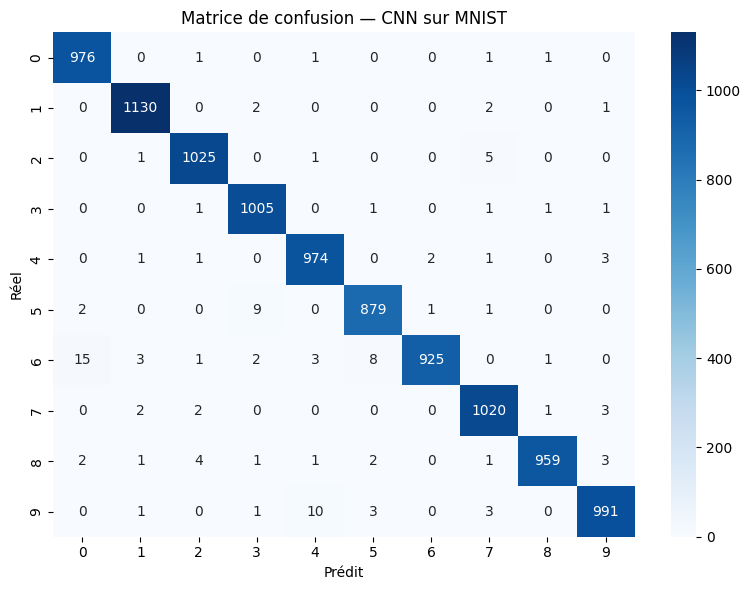

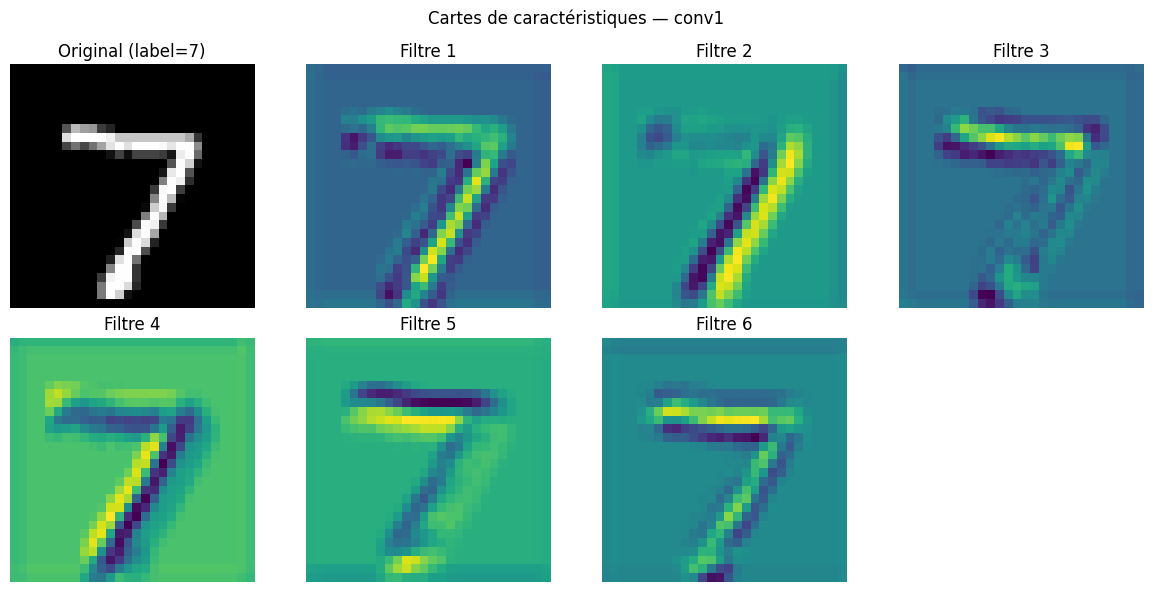

Partie II terminée ✓ — graphiques sauvegardés


In [ ]:

# ── Métriques finales CNN ────────────────────────────────
cnn_model.load_state_dict(torch.load("best_cnn.pth", map_location=device))
cnn_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        all_preds.extend(cnn_model(xb).argmax(1).cpu().numpy())
        all_labels.extend(yb.numpy())

print("\n=== Rapport de classification CNN ===")
print(classification_report(all_labels, all_preds))

# ── Matrice de confusion ─────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion — CNN sur MNIST")
plt.ylabel("Réel"); plt.xlabel("Prédit")
plt.tight_layout()
plt.savefig("confusion_cnn.png", dpi=150)
plt.show()

# ── Visualisation des cartes de caractéristiques ─────────
# On prend une image du test set et on regarde ce que voit conv1
img_sample, label_sample = test_dataset[0]
img_input = img_sample.unsqueeze(0).to(device)   # [1,1,28,28]

# Extraire la sortie de conv1 (avant pooling)
activation = {}
def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

cnn_model.conv1.register_forward_hook(get_activation("conv1"))
with torch.no_grad():
    _ = cnn_model(img_input)

feature_maps = activation["conv1"].squeeze().cpu()  # [6, 28, 28]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
# Image originale
axes[0, 0].imshow(img_sample.squeeze(), cmap="gray")
axes[0, 0].set_title(f"Original (label={label_sample})")
axes[0, 0].axis("off")
# 6 cartes de caractéristiques de conv1
for i in range(6):
    row, col = (i+1) // 4, (i+1) % 4
    axes[row, col].imshow(feature_maps[i], cmap="viridis")
    axes[row, col].set_title(f"Filtre {i+1}")
    axes[row, col].axis("off")
axes[1, 3].axis("off")  # case vide

plt.suptitle("Cartes de caractéristiques — conv1")
plt.tight_layout()
plt.savefig("feature_maps.png", dpi=150)
plt.show()
print("Partie II terminée ✓ — graphiques sauvegardés")
